# Deep learning applied to gravitational lensing

## Import parameters

In [1]:
import pandas as pd

df = pd.read_csv("mock_lenses_hsc.csv")
df

,objID,objID_src,rot,x_lens,y_lens,q,PA,r_Einstein,z_source,z_lens,velDisp,x_source,y_source,boost,shear,shear_PA
0,1,1090,0,0.038127,-0.083938,0.832873,1.099377,2.454128,3.127611,0.730786,378.07416,-0.279477,-0.477602,-1.0,0.022431,0.911779
1,2,426,0,-0.082791,-0.109870,0.742644,1.852767,2.468242,5.798559,0.441585,329.32822,-0.074636,-0.380427,-3.0,0.059983,0.958381
2,3,2136,0,-0.054644,-0.008364,0.845785,2.936826,2.475322,4.785457,0.454826,333.96304,-0.133183,-0.277230,-3.0,0.038890,1.134869
3,4,7141,0,-0.030885,-0.070501,0.857919,2.483655,2.456651,4.792636,0.819645,369.14502,-0.133090,-0.034229,-4.0,0.005173,2.657499
4,5,7215,0,-0.038541,0.001391,0.899268,0.382301,2.497800,4.860585,0.703609,359.74615,-0.318418,-0.027564,-4.0,0.043490,1.112804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43728,51996,1083,1,0.012901,-0.058693,0.867499,1.836198,0.776824,0.827810,0.415259,248.21088,0.057228,-0.057947,-4.0,0.054220,2.249565
43729,51997,12,2,-0.001551,0.024924,0.808340,2.464540,0.756855,0.996663,0.422812,228.52315,-0.070151,-0.063773,-3.0,0.029062,2.235106
43730,51998,11,0,0.006303,-0.002664,0.750802,2.697964,0.792795,1.037593,0.484768,245.66832,-0.018803,-0.008539,-1.0,0.045575,2.531362
43731,51999,1273,0,0.046707,0.056492,0.853459,1.348237,0.786784,2.172062,0.494431,204.68020,0.006797,-0.021310,-1.0,0.041806,2.955045


## Ellipticity

Compute $e_x$ and $e_y$

where :
$$e_x = \text{cos}(2\theta)\frac{1-q^2}{1+q^2} \quad \text{and} \quad e_y = \text{sin}(2\theta)\frac{1-q^2}{1+q^2}$$

and :
$$q = \frac{\sqrt{1 - \sqrt{e_x^2 + e_y^2}}}{\sqrt{1 + \sqrt{e_x^2 + e_y^2}}}$$


In [2]:
import numpy as np
df['ex'] = np.cos(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)
df['ey'] = np.sin(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)

In [3]:
df['qq'] = np.sqrt((1 - np.sqrt(df.ex **2 + df.ey**2)) / (1 + np.sqrt(df.ex **2 + df.ey**2)) )
df['diff'] = df.q - df.qq

## Shear

Compute $\gamma_{ext,1}$ and $\gamma_{ext,2}$
where:
$$\gamma_{ext, 1} = \text{cos}(2\theta) \ \gamma_{ext} \quad \text{and} \quad \gamma_{ext, 2} = \text{sin}(2\theta) \ \gamma_{ext}$$
and :
$$\gamma_{ext} = \sqrt{\gamma_{ext, 1}^2 + \gamma_{ext,2}^2}$$

In [4]:
df['gamma1'] = np.cos(2 * df.shear_PA) * df.shear
df['gamma2'] = np.sin(2 * df.shear_PA) * df.shear

## Distribution of the dataset

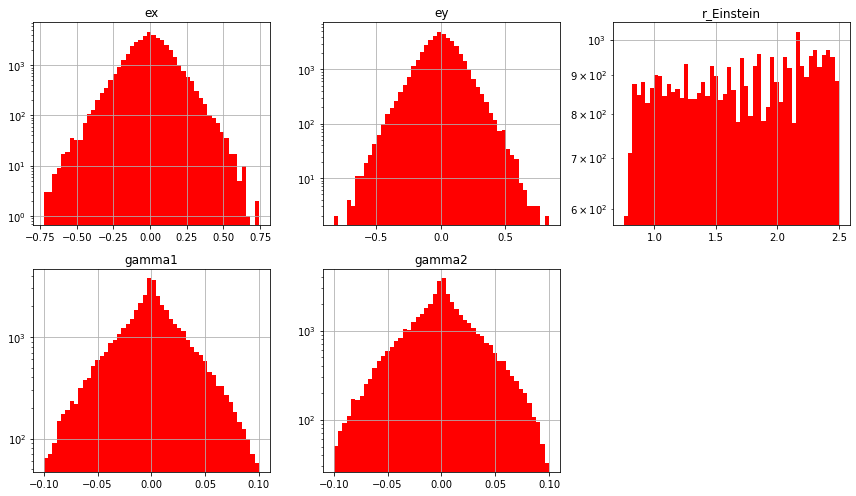

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()   
columns = ["ex", "ey", "r_Einstein", "gamma1", "gamma2"]

for i, col in enumerate(columns):
    axes[i].hist(df[col], bins=50, color='red', alpha=1, log=True)
    axes[i].set_title(col)
    axes[i].grid(True)

# axes[-2].axis("off")
axes[-1].axis("off")

plt.tight_layout()
plt.show()

## Images

In [6]:
import os
os.chdir("/home/rcanameras/data/mock_lenses_hsc/")
# os.chdir("/home/mbatt")

In [7]:
folders = [f for f in os.listdir() if 'csv' not in f]

dict_im = {}
for fold in folders: 
    for file in os.listdir(fold):
        if '.fits' in file:
            objID = int(file.split('_')[1])
            dict_im[objID] = [fold + "/" + file]

In [8]:
df_im = pd.DataFrame(dict_im).T
df_im = df_im.reset_index()
df_im.columns = ["objID", "location"]

In [9]:
df_full = df.merge(df_im, on = "objID", how = 'left')

In [10]:
df_sample = df_full#.sample(n=2000, random_state=42)

In [11]:
import os
os.chdir("/home/mbatt")

In [12]:
image_index = 9

## Images raw

Opening: /home/rcanameras/data/mock_lenses_hsc/final_hscsearch_2e3_1/lens_12_source_1225_r_0.fits


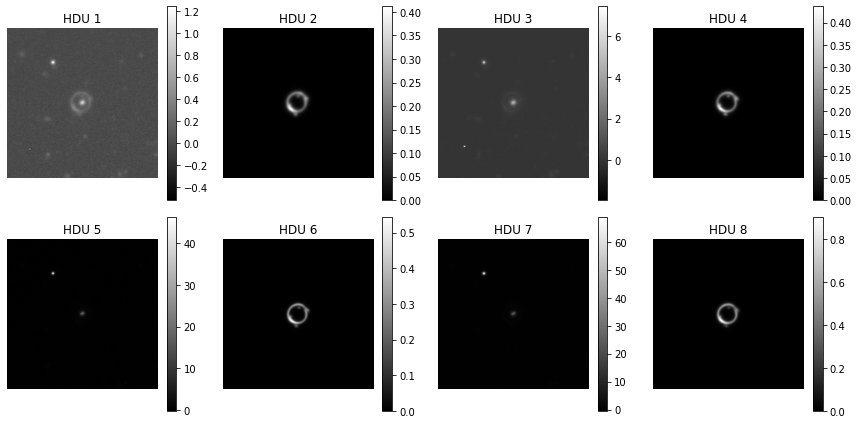

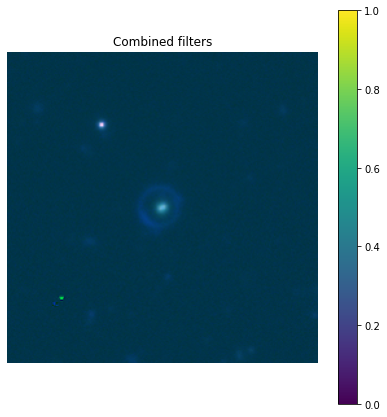

In [13]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import os
import random

folder = "/home/rcanameras/data/mock_lenses_hsc"
file = os.path.join(folder, df_sample.location.values[image_index])
print("Opening:", file)

with fits.open(file) as hdul:
    images = [hdul[i].data for i in range(1, len(hdul))]
    
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, img, idx in zip(axes.ravel(), images, range(1, len(images)+1)):
    im = ax.imshow(img, origin='lower', cmap='gray')
    fig.colorbar(im, ax=ax)
    ax.set_title(f"HDU {idx}")
    ax.axis('off')

plt.tight_layout()
plt.show()

with fits.open(file) as hdul:
    g = hdul[1].data
    r = hdul[3].data
    i = hdul[5].data
    z = hdul[7].data
    
R, G, B = i, r, g

def norm(x):
    x = x - np.nanmin(x)
    x = x / np.nanmax(x)
    return x

Rn, Gn, Bn = norm(R), norm(G), norm(B)

rgb = np.dstack([Rn, Gn, Bn])

plt.figure(figsize=(6,6))
plt.imshow(rgb, origin='lower')
plt.tight_layout()
plt.axis('off')
plt.title("Combined filters")
plt.colorbar()
plt.show()

In [14]:
import torch
from astropy.io import fits
import numpy as np

def save_fits_as_tensor(arr, save_path):
    # arr is dimension 8
    tensor = torch.tensor(arr, dtype=torch.float32)
    torch.save(tensor, save_path)

In [15]:
path_image = "/net/CLUSTER/VAULT/users/rcanameras/data/mock_lenses_hsc/"
save_path = "/net/CLUSTER/VAULT/users/mbatt/data/"

In [16]:
# import random
# from tqdm import tqdm
# import os

# w1, w2 = 40, 180 # image will be of dimension w2-w1 x w2-w1
# LL = [f for f in os.listdir(save_path)]

# for ima_file in tqdm(df_sample.location[35510:]):
#     x = torch.load("/home/mbatt/data/"+ ima_file.split('/')[1] + ".pt")
#     if x.shape[0] != 8:
# #         ima_file = 'final_hscsearch_2e3_23/lens_45869_source_1366_r_2.fits'
#         with fits.open(path_image + ima_file) as hdul:
#             c = random.randint(0, w1)
#             images = [hdul[i].data[w1+c:w2+c,w1+c:w2+c] for i in range(1, len(hdul))]
#             arr = np.stack(images, axis=0)
#             save_fits_as_tensor(arr, save_path + ima_file.split('/')[1] + ".pt")

In [17]:
# import random
# from tqdm import tqdm
# import os

# w1, w2 = 40, 180 # image will be of dimension w2-w1 x w2-w1
# LL = [f for f in os.listdir(save_path)]

# for ima_file in tqdm(df_sample.location[:10]):
#     if ima_file.split('/')[1] + '.pt' not in LL:
#         with fits.open(path_image + ima_file) as hdul:
#             c = random.randint(0, w1)
#             images = [hdul[i].data[w1+c:w2+c,w1+c:w2+c] for i in range(1, len(hdul))]
#             arr = np.stack(images, axis=0)
#             save_fits_as_tensor(arr, save_path + ima_file.split('/')[1] + ".pt")

## Images reformated

Found FITS: 43734
Opening: /net/CLUSTER/VAULT/users/mbatt/data/lens_12_source_1225_r_0.fits.pt


/tmp/ipykernel_266449/4083360855.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  images = torch.load(file)[::2]


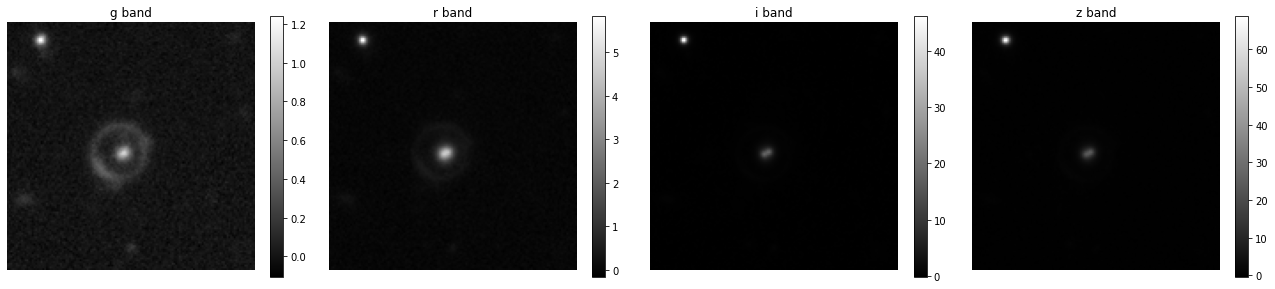

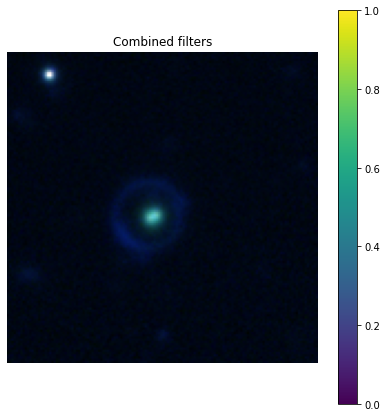

In [18]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import os
import random

folder =  "/net/CLUSTER/VAULT/users/mbatt/data/"
fits_files = [f for f in os.listdir(folder)]
print("Found FITS:", len(fits_files))

file = os.path.join(folder, df_sample.location.values[image_index].split("/")[1] + ".pt")
images = torch.load(file)[::2]
print("Opening:", file)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

bandes = ['g', 'r', 'i', 'z']
for ax, img, idx in zip(axes.ravel(), images, range(1, len(images)+1)):
    im = ax.imshow(img, origin='lower', cmap='gray')
    fig.colorbar(im, ax=ax)
    ax.set_title(f"{bandes[idx-1]} band")
    ax.axis('off')

plt.tight_layout()
plt.show()

g = images[0]
r = images[1]
i = images[2]
z = images[3]
    
R, G, B = i, r, g

def norm(x):
    x = x - np.nanmin(x)
    x = x / np.nanmax(x)
    return x

Rn, Gn, Bn = norm(R), norm(G), norm(B)

rgb = np.dstack([Rn, Gn, Bn])

plt.figure(figsize=(6,6))
plt.imshow(rgb, origin='lower')
plt.tight_layout()
plt.axis('off')
plt.title("Combined filters")
plt.colorbar()
plt.show()

# Deep learning models

In [19]:
df_sample

,objID,objID_src,rot,x_lens,y_lens,q,PA,r_Einstein,z_source,z_lens,...,boost,shear,shear_PA,ex,ey,qq,diff,gamma1,gamma2,location
0,1,1090,0,0.038127,-0.083938,0.832873,1.099377,2.454128,3.127611,0.730786,...,-1.0,0.022431,0.911779,-0.106255,0.146359,0.832873,1.110223e-16,-0.005610,0.021719,final_hscsearch_2e3_1/lens_1_source_1090_r_0.fits
1,2,426,0,-0.082791,-0.109870,0.742644,1.852767,2.468242,5.798559,0.441585,...,-3.0,0.059983,0.958381,-0.244299,-0.154508,0.742644,-1.110223e-16,-0.020340,0.056429,final_hscsearch_2e3_1/lens_2_source_426_r_0.fits
2,3,2136,0,-0.054644,-0.008364,0.845785,2.936826,2.475322,4.785457,0.454826,...,-3.0,0.038890,1.134869,0.152219,-0.066075,0.845785,0.000000e+00,-0.025022,0.029771,final_hscsearch_2e3_1/lens_3_source_2136_r_0.fits
3,4,7141,0,-0.030885,-0.070501,0.857919,2.483655,2.456651,4.792636,0.819645,...,-4.0,0.005173,2.657499,0.038344,-0.147143,0.857919,0.000000e+00,0.002932,-0.004262,final_hscsearch_2e3_1/lens_4_source_7141_r_0.fits
4,5,7215,0,-0.038541,0.001391,0.899268,0.382301,2.497800,4.860585,0.703609,...,-4.0,0.043490,1.112804,0.076335,0.073224,0.899268,0.000000e+00,-0.026486,0.034495,final_hscsearch_2e3_1/lens_5_source_7215_r_0.fits
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43728,51996,1083,1,0.012901,-0.058693,0.867499,1.836198,0.776824,0.827810,0.415259,...,-4.0,0.054220,2.249565,-0.121763,-0.071475,0.867499,0.000000e+00,-0.011475,-0.052992,final_hscsearch_2e3_26/lens_51996_source_1083_...
43729,51997,12,2,-0.001551,0.024924,0.808340,2.464540,0.756855,0.996663,0.422812,...,-3.0,0.029062,2.235106,0.045068,-0.204716,0.808340,0.000000e+00,-0.006970,-0.028214,final_hscsearch_2e3_26/lens_51997_source_12_r_...
43730,51998,11,0,0.006303,-0.002664,0.750802,2.697964,0.792795,1.037593,0.484768,...,-1.0,0.045575,2.531362,0.176209,-0.216331,0.750802,-1.110223e-16,0.015642,-0.042806,final_hscsearch_2e3_26/lens_51998_source_11_r_...
43731,51999,1273,0,0.046707,0.056492,0.853459,1.348237,0.786784,2.172062,0.494431,...,-1.0,0.041806,2.955045,-0.141833,0.067661,0.853459,0.000000e+00,0.038930,-0.015238,final_hscsearch_2e3_26/lens_51999_source_1273_...


In [20]:
dff = df_sample[['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey', 'location']]
dff = dff.set_index("location")

# Normalization of the parameters

In [21]:
cols_to_norm = ['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey']
dff[cols_to_norm] = (dff[cols_to_norm] - dff[cols_to_norm].min()) / (dff[cols_to_norm].max() - dff[cols_to_norm].min())

In [22]:
# cols_to_norm = ['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey']

# means = dff[cols_to_norm].mean()
# stds = dff[cols_to_norm].std()

# dff[cols_to_norm] = (dff[cols_to_norm] - means) / stds

In [23]:
dff = dff.sample(frac=1, random_state=42)

In [24]:
dff.to_csv('/home/mbatt/gravitational_lensing/ready_data.csv')

In [25]:
import pandas as pd
dff = pd.read_csv('/home/mbatt/gravitational_lensing/ready_data.csv', index_col = 0)

## Load data

In [26]:
from deep_learning_models import *
from deep_learning_models import LensDataset

In [27]:
import torch
from torch.utils.data import random_split

path_tensor = "/home/mbatt/data"
full_dataset = LensDataset_UNet(dff, path_tensor)

train_loader, val_loader, test_loader = full_dataset.split_data(training_pct = 0.6, # 60% for training
                                                                test_pct = 0.2, # 20% for test
                                                                batch_size = 32)

## Import Models

In [28]:
from deep_learning_models import UNet

In [29]:
import os
os.chdir("/home/mbatt/gravitational_lensing")

In [30]:
# model = ResNetMini()   
# model = ResNetHoliSmokes()
# model = BayesianResNetMini()
model = UNet()

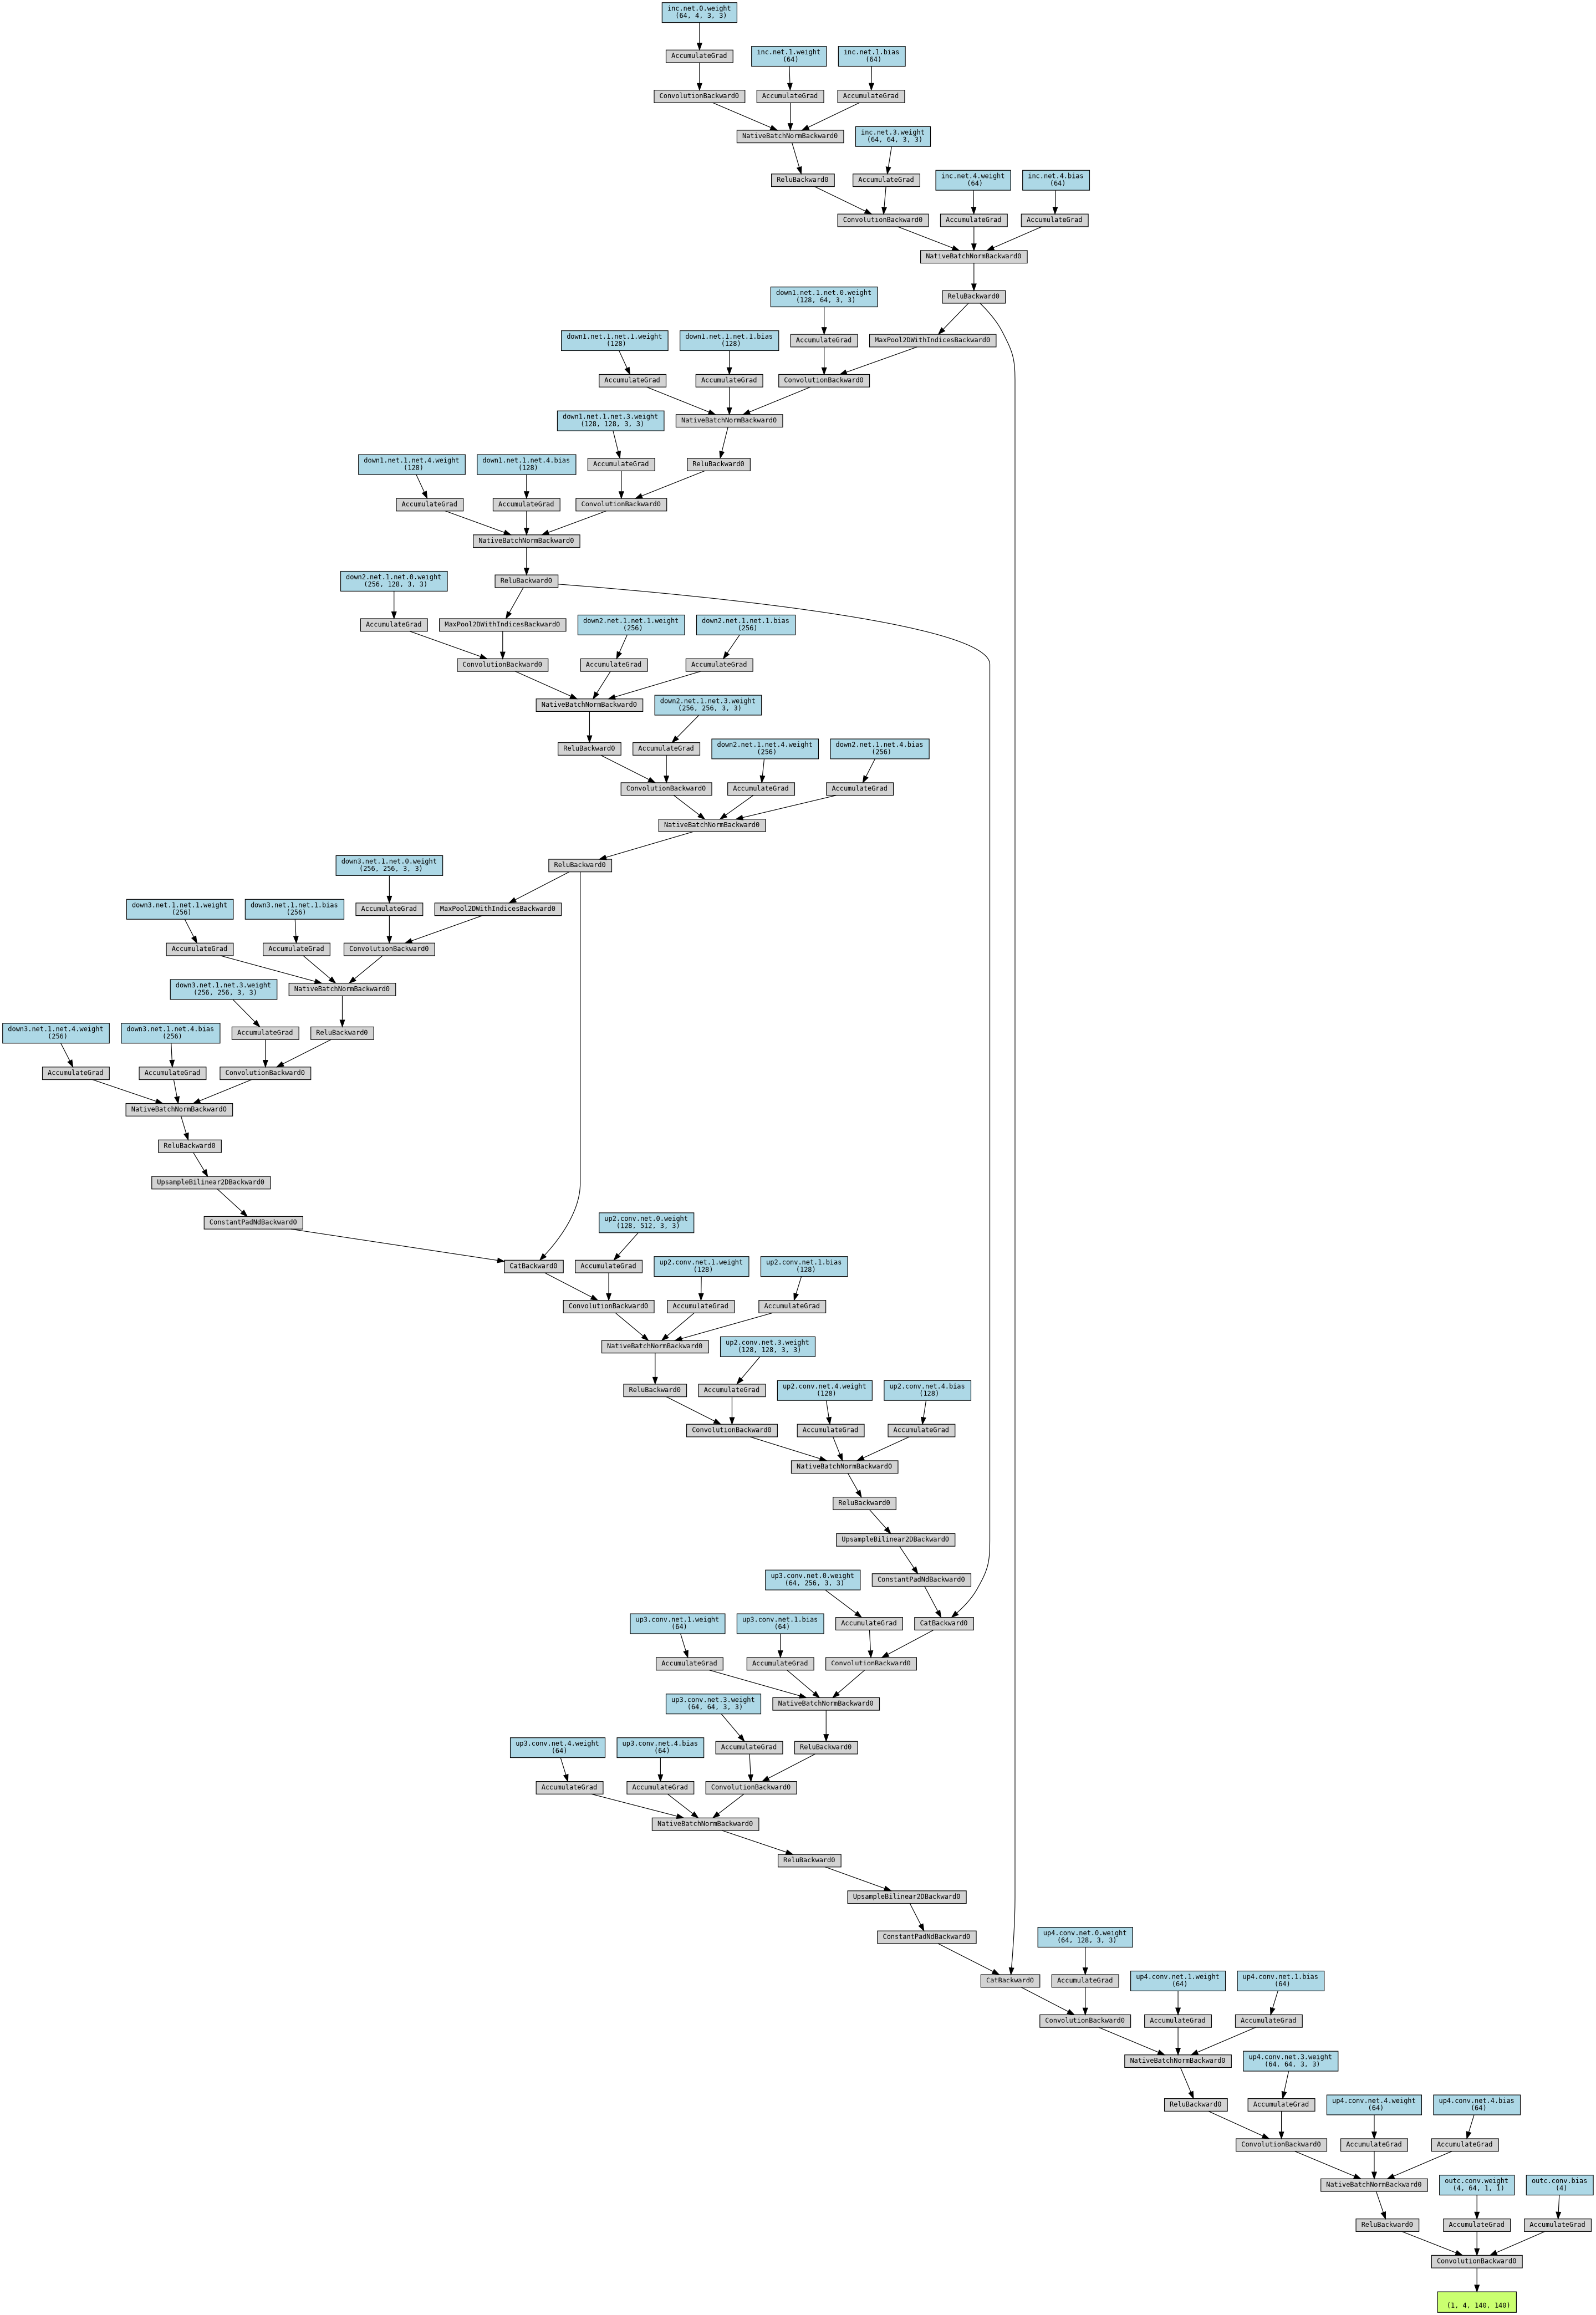

In [31]:
v = viewer(model)
v.show_model()
Image("resnetmini.png")

In [34]:
from process_training import Trainer
import warnings
warnings.filterwarnings("ignore")

In [35]:
Train_model = Trainer(model = model,
                      learning_rate = 1e-3,
                      scheduler_coef = 0.1                  
)

In [10]:
Train_model.run_unet(epochs = 60,
                training_set = train_loader, 
                validation_set = val_loader)

KeyboardInterrupt: 

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
import os

os.chdir("/home/mbatt/gravitational_lensing/UNet_weights")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-5)

checkpoint = torch.load(f"{model.model_name}_2.pth", map_location=device)

model.load_state_dict(checkpoint["model"])
optimizer.load_state_dict(checkpoint["optimizer"])
start_epoch = checkpoint["epoch"] + 1

train_losses = checkpoint["train_losses"]
val_losses = checkpoint["val_losses"]

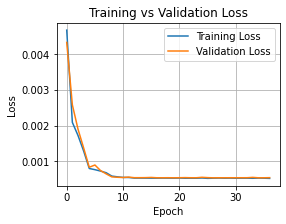

In [37]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,3))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/unet_loss.png")
plt.show()


In [83]:
model.eval()
preds = []
targets = []
inpute = []

criterion = nn.MSELoss(reduction="none")
with torch.no_grad():
    for xb, yb in test_loader:   # <-- use test_loader here
        xb, xout = xb[0].to(device), xb[1].to(device)
        yb = yb.to(device)

        out = model(xb)

        preds.append(out.cpu())
        targets.append(xout.cpu())
        inpute.append(xb.cpu())
        break

# concatenate all batches
preds = torch.cat(preds)      
targets = torch.cat(targets)  
inpute = torch.cat(inpute)

# # compute per-parameter MSE
# loss = criterion(preds, targets)   # shape (N, 5)
# mse = loss.mean(dim=0)             # shape (5,)

# print("Per-parameter MSE:", mse)

# # --- Compute R2 per parameter ---
# y_true_np = targets.numpy()
# y_pred_np = preds.numpy()

# r2_scores = []
# for i in range(5):
#     ss_res = np.sum((y_true_np[:, i] - y_pred_np[:, i])**2)
#     ss_tot = np.sum((y_true_np[:, i] - np.mean(y_true_np[:, i]))**2)
#     r2 = 1 - ss_res / ss_tot
#     r2_scores.append(r2)

# print("Per-parameter R2:", r2_scores)


In [84]:
preds.shape

torch.Size([32, 4, 140, 140])

In [85]:
targets.shape

torch.Size([32, 4, 140, 140])

In [86]:
batch_idx = 9
pred = preds[batch_idx]   # shape (4, 140, 140)
targ = targets[batch_idx]       # shape (4, 140, 140)
inpu = inpute[batch_idx]

MSE per band (g, r, i, z): [0.00010933 0.00023769 0.00051127 0.00093433]
Global MSE: 0.00044815493


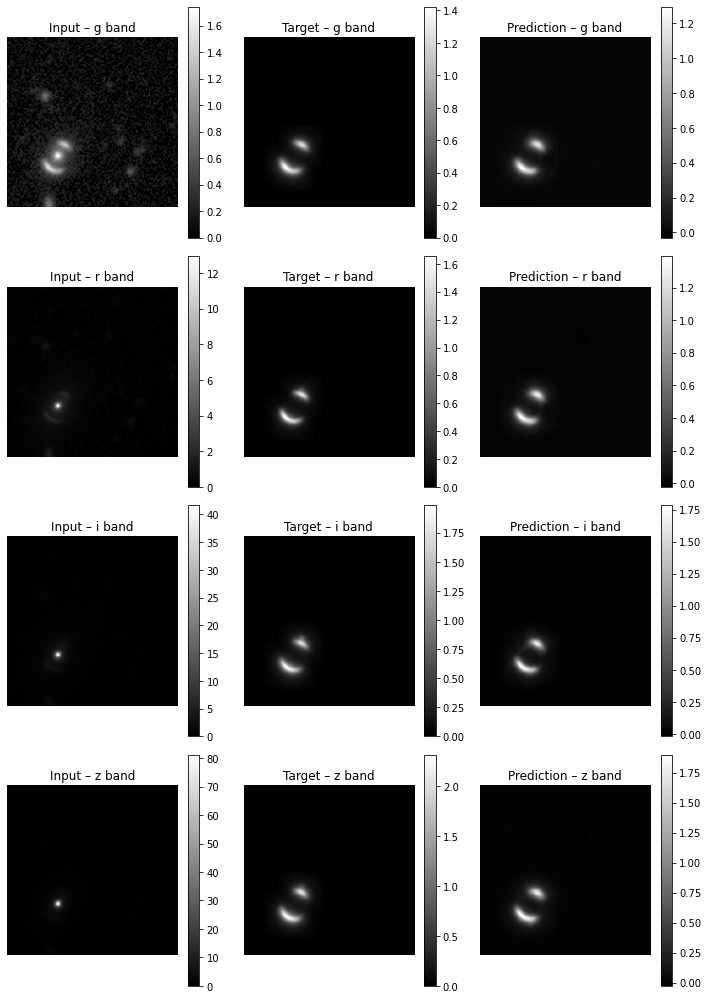

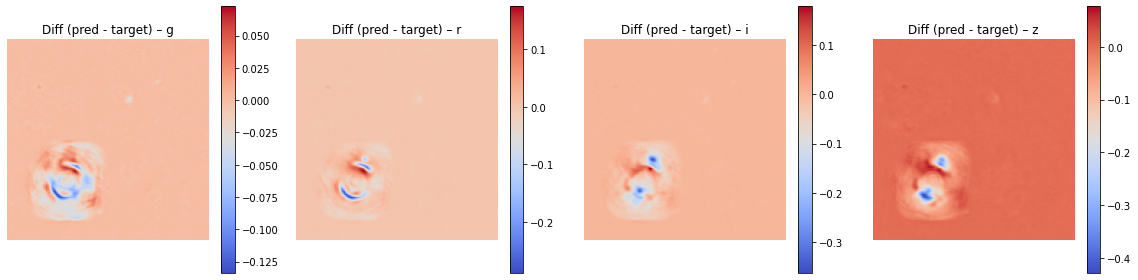

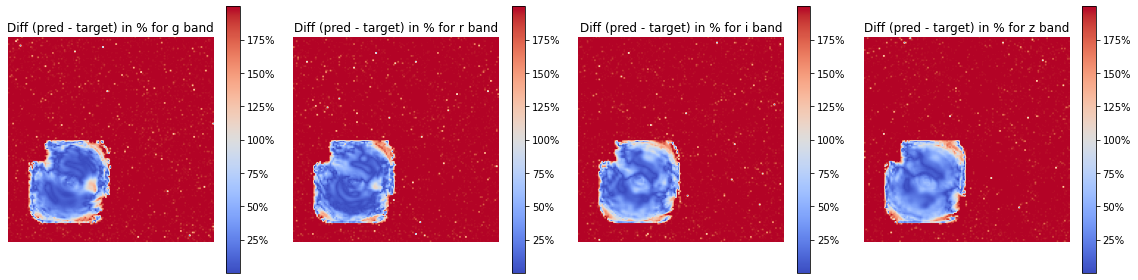

In [87]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pred_np = pred.cpu().numpy()
targ_np = targ.cpu().numpy()
inpu_np = inpu.cpu().numpy()

# --- sinh transform ---
def transform(x):
    return np.sinh(x)

pred_np = transform(pred_np)
targ_np = transform(targ_np)
inpu_np = transform(inpu_np)

# --- compute MSE per band ---
mse_per_band = ((pred_np - targ_np) ** 2).mean(axis=(1,2))
global_mse = ((pred_np - targ_np) ** 2).mean()

print("MSE per band (g, r, i, z):", mse_per_band)
print("Global MSE:", global_mse)

bandes = ['g', 'r', 'i', 'z']

# --- Plot predictions (left) and targets (right) ---
fig, axes = plt.subplots(4, 3, figsize=(10, 14))

for i in range(4):
    # Prediction
    ax_pred = axes[i, 2]
    im_pred = ax_pred.imshow(pred_np[i], origin='lower', cmap='gray')
    fig.colorbar(im_pred, ax=ax_pred)
    ax_pred.set_title(f"Prediction – {bandes[i]} band")
    ax_pred.axis('off')

    # Target
    ax_targ = axes[i, 1]
    im_targ = ax_targ.imshow(targ_np[i], origin='lower', cmap='gray')
    fig.colorbar(im_targ, ax=ax_targ)
    ax_targ.set_title(f"Target – {bandes[i]} band")
    ax_targ.axis('off')
    
    # Inpute
    ax_inpu = axes[i, 0]
    im_inpu = ax_inpu.imshow(inpu_np[i], origin='lower', cmap='gray')
    fig.colorbar(im_inpu, ax=ax_inpu)
    ax_inpu.set_title(f"Input – {bandes[i]} band")
    ax_inpu.axis('off')

plt.tight_layout()
plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/UNet_image_pred.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Optional: difference maps ---
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    diff = pred_np[i] - targ_np[i]
    ax = axes[i]
    im = ax.imshow(diff, origin='lower', cmap='coolwarm')
    fig.colorbar(im, ax=ax)
    ax.set_title(f"Diff (pred - target) – {bandes[i]}")
    ax.axis('off')

plt.tight_layout()
plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/UNet_diff_image_pred.png", dpi=300, bbox_inches="tight")
plt.show()


# --- Optional: difference maps ---
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    pred = pred_np[i]
    targ = targ_np[i]
    eps = 1e-6
    pct = 2 * np.abs(pred - targ) / (np.abs(pred) + np.abs(targ) + eps)
    ax = axes[i]
    im = ax.imshow(pct, origin='lower', cmap='coolwarm')
#     fig.colorbar(im, ax=ax)
    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(f"Diff (pred - target) in % for {bandes[i]} band")
    ax.axis('off')

plt.tight_layout()
plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/UNet_diff_image_pred_pct.png", dpi=300, bbox_inches="tight")

plt.show()



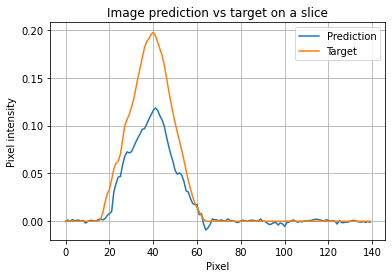

In [88]:
line = 20
plt.figure(figsize=(6,4))
plt.plot(pred_np[i][line], label = 'Prediction')
plt.plot(targ_np[i][line], label = 'Target')
plt.legend()
plt.xlabel('Pixel')
plt.ylabel('Pixel intensity')
plt.title('Image prediction vs target on a slice')
plt.grid()
plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/UNet_slice.png", dpi=300, bbox_inches="tight")

plt.show()

In [45]:
pred_np[i]

array([[ 1.7567398e-03,  4.3321052e-03,  1.1804367e-03, ...,
        -7.1760267e-05,  2.9942766e-04, -9.1992703e-04],
       [ 1.0660479e-03,  3.4357235e-04,  2.7794391e-05, ...,
         1.7503882e-03, -2.2202358e-04, -1.7312065e-03],
       [ 2.7835441e-03, -3.9919838e-04,  1.0843540e-03, ...,
         1.9412488e-05, -3.5645440e-04, -9.8288443e-04],
       ...,
       [ 6.8048394e-04,  2.2770893e-03, -5.5617467e-04, ...,
        -8.4039953e-04, -7.9613930e-04,  5.5139884e-04],
       [ 1.6682968e-04, -3.2620504e-04,  7.1339309e-06, ...,
        -9.7315031e-04, -1.5068097e-03,  3.1853467e-04],
       [ 2.1892413e-04,  1.4489484e-03, -1.8335703e-03, ...,
        -5.8649486e-04, -4.6302754e-04,  4.4390443e-03]], dtype=float32)

In [46]:
targ_np[i]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

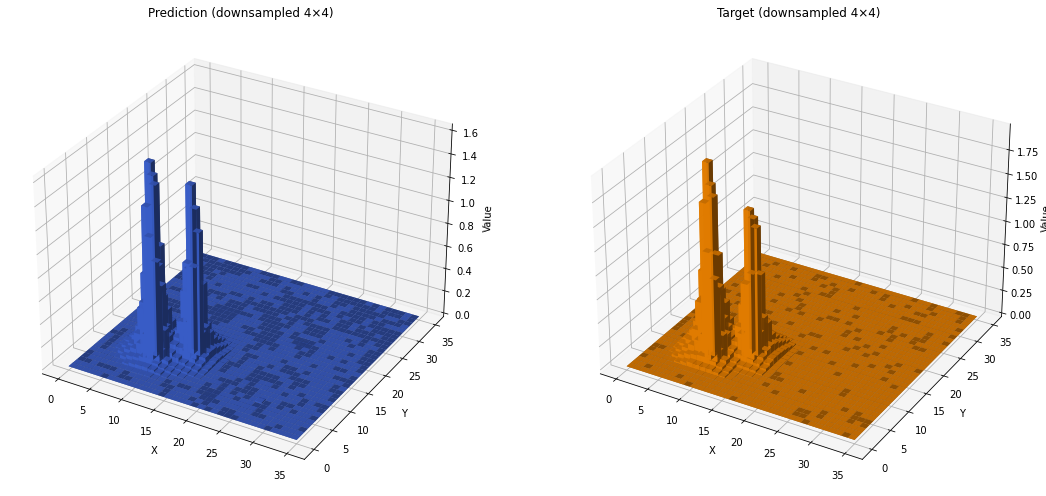

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# pred and targ are tensors of shape (4, 140, 140)
# choose one band, e.g. i-band (index 2)
pred_arr = pred_np[i]
targ_arr = targ_np[i]

# --- Downsample by averaging 4×4 blocks ---
def downsample_4x4(arr):
    h, w = arr.shape
    arr = arr[:h - (h % 4), :w - (w % 4)]  # ensure divisible by 4
    arr = arr.reshape(h//4, 4, w//4, 4).mean(axis=(1, 3))
    return arr

pred_ds = downsample_4x4(pred_arr)   # shape (35, 35)
targ_ds = downsample_4x4(targ_arr)   # shape (35, 35)

# --- Prepare grid for bar3d ---
nx, ny = pred_ds.shape
x = np.arange(nx)
y = np.arange(ny)
xx, yy = np.meshgrid(x, y, indexing='ij')

x_flat = xx.ravel()
y_flat = yy.ravel()
z_flat = np.zeros_like(x_flat)

pred_flat = pred_ds.ravel()
targ_flat = targ_ds.ravel()

dx = dy = 1

# --- Plot side-by-side ---
fig = plt.figure(figsize=(16, 7))

# LEFT: prediction
ax1 = fig.add_subplot(121, projection='3d')
ax1.bar3d(x_flat, y_flat, z_flat, dx, dy, pred_flat,
          shade=True, color='royalblue', alpha=0.9)
ax1.set_title("Prediction (downsampled 4×4)")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Value")

# RIGHT: target
ax2 = fig.add_subplot(122, projection='3d')
ax2.bar3d(x_flat, y_flat, z_flat, dx, dy, targ_flat,
          shade=True, color='darkorange', alpha=0.9)
ax2.set_title("Target (downsampled 4×4)")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Value")

plt.tight_layout()
plt.show()


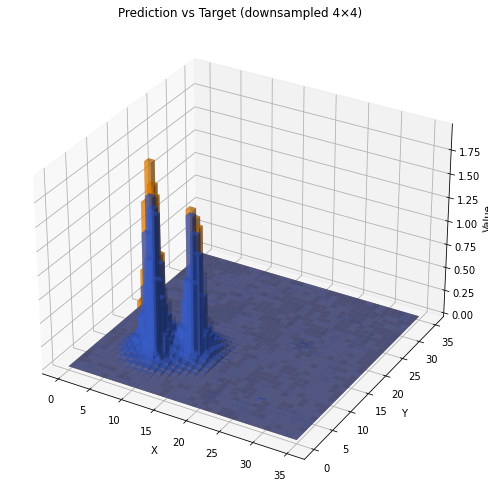

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# pred and targ are arrays of shape (4, 140, 140)
pred_arr = pred_np[i]
targ_arr = targ_np[i]

# --- Downsample by averaging 4×4 blocks ---
def downsample_4x4(arr):
    h, w = arr.shape
    arr = arr[:h - (h % 4), :w - (w % 4)]
    arr = arr.reshape(h//4, 4, w//4, 4).mean(axis=(1, 3))
    return arr

pred_ds = downsample_4x4(pred_arr)
targ_ds = downsample_4x4(targ_arr)

# --- Prepare grid ---
nx, ny = pred_ds.shape
x = np.arange(nx)
y = np.arange(ny)
xx, yy = np.meshgrid(x, y, indexing='ij')

x_flat = xx.ravel()
y_flat = yy.ravel()
z_flat = np.zeros_like(x_flat)

pred_flat = pred_ds.ravel()
targ_flat = targ_ds.ravel()

dx = dy = 1

# --- Plot both on the SAME axes ---
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Prediction bars
ax.bar3d(
    x_flat, y_flat, z_flat,
    dx, dy, pred_flat,
    color='royalblue', alpha=0.5, shade=True,
    label='Prediction'
)

# Target bars
ax.bar3d(
    x_flat, y_flat, z_flat,
    dx, dy, targ_flat,
    color='darkorange', alpha=0.5, shade=True,
    label='Target'
)

ax.set_title("Prediction vs Target (downsampled 4×4)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Value")

plt.tight_layout()
plt.show()


In [38]:
model.eval()
preds = []
targets = []
inpute = []
MSE = []

criterion = nn.MSELoss(reduction="none")
with torch.no_grad():
    for xb, yb in test_loader:   # <-- use test_loader here
        xb, xout = xb[0].to(device), xb[1].to(device)
        yb = yb.to(device)

        out = model(xb)
        
        mse = torch.mean((out - xout)**2, dim=(2, 3))
        MSE.append(mse.cpu())

# concatenate all batches
MSE = torch.cat(MSE, dim = 0)      

In [39]:
MSE.shape

torch.Size([8746, 4])

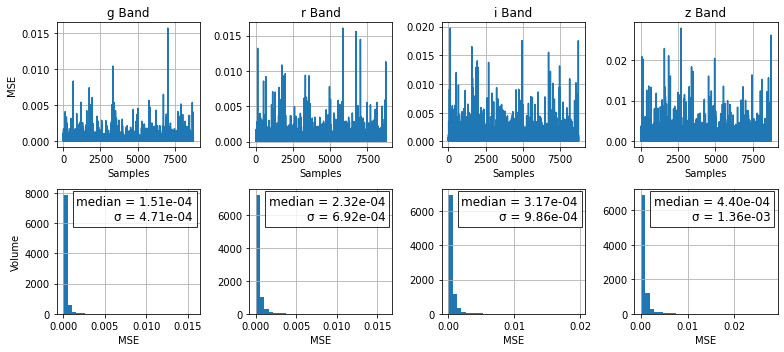

In [49]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(11, 5))
bandes = ['g', 'r', 'i', 'z']
mean_squarre = MSE.numpy()

for i in range(4):
    # Top row: MSE curves
    axes[0, i].set_title(f"{bandes[i]} Band")
    axes[0, i].plot(MSE[:, i])
    axes[0, i].set_xlabel("Samples")
    axes[0, i].grid(True)

    # Bottom row: histograms
    ax = axes[1, i]
    ax.grid(True)
    ax.hist(MSE[:, i], bins=30)
    ax.set_xlabel("MSE")

    # Compute stats
    mean_val = np.median(mean_squarre[:, i])
    sigma_val = np.std(mean_squarre[:, i])

    # Add text box
#     textstr = f"median = {mean_val:.2e}\nσ = {sigma_val:.2e}"
    
    text = (
        f"median = {mean_val:.2e}\n"
        f"σ = {sigma_val:.2e}"
    )

    ax.text(
        0.95, 0.95, text,
        transform=ax.transAxes,
        fontsize=12,
        ha="right", va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
    )


axes[0, 0].set_ylabel("MSE")
axes[1, 0].set_ylabel("Volume")
plt.tight_layout()
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/UNet_mse.png", dpi=300, bbox_inches="tight")
plt.show()


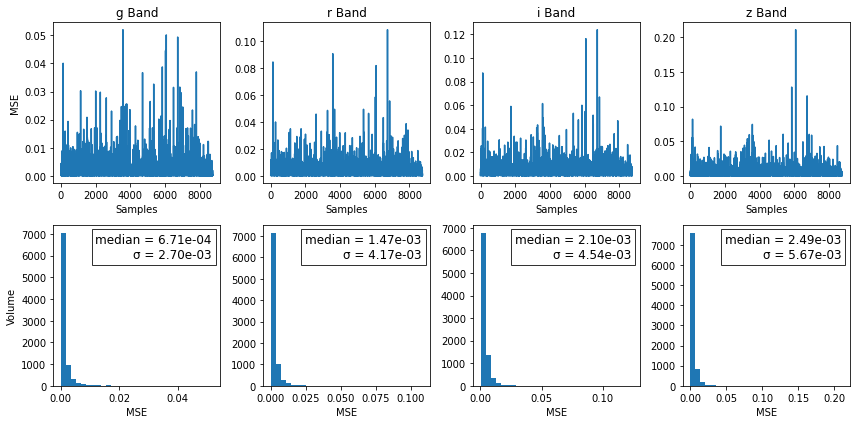

In [48]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
bandes = ['g', 'r', 'i', 'z']
mean_squarre = MSE.numpy()

for i in range(4):
    # Top row: MSE curves
    axes[0, i].set_title(f"{bandes[i]} Band")
    axes[0, i].plot(MSE[:, i])
    axes[0, i].set_xlabel("Samples")

    # Bottom row: histograms
    ax = axes[1, i]
    ax.hist(MSE[:, i], bins=30)
    ax.set_xlabel("MSE")

    # Compute stats
    mean_val = np.median(mean_squarre[:, i])
    sigma_val = np.std(mean_squarre[:, i])

    # Add text box
#     textstr = f"median = {mean_val:.2e}\nσ = {sigma_val:.2e}"
    
    text = (
        f"median = {mean_val:.2e}\n"
        f"σ = {sigma_val:.2e}"
    )

    ax.text(
        0.95, 0.95, text,
        transform=ax.transAxes,
        fontsize=12,
        ha="right", va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
    )


axes[0, 0].set_ylabel("MSE")
axes[1, 0].set_ylabel("Volume")

plt.tight_layout()
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/UNet_mse_22.png", dpi=300, bbox_inches="tight")
plt.show()


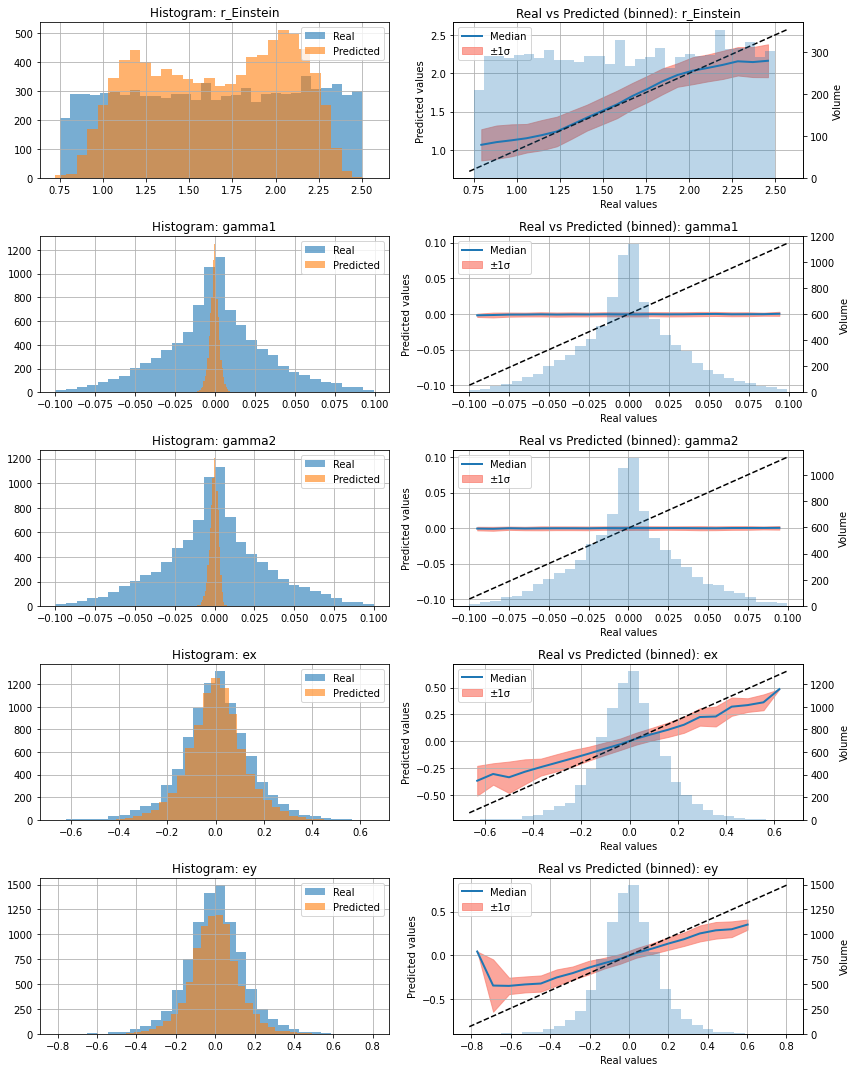

In [54]:
# import matplotlib.pyplot as plt
# import numpy as np

# # # Min/max used for normalization
# # df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].main().values
# # df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

# # # Convert to numpy
# # y_true = targets.numpy()
# # y_pred = preds.numpy()

# # # --- DENORMALIZATION ---
# # y_true_denorm = y_true * (df_max - df_min) + df_min
# # y_pred_denorm = y_pred * (df_max - df_min) + df_min

# param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

# plt.figure(figsize=(12, 15))

# for i in range(5):

#     # --- METRICS ---
#     ss_res = np.sum((y_true_denorm[:, i] - y_pred_denorm[:, i])**2)
#     ss_tot = np.sum((y_true_denorm[:, i] - np.mean(y_true_denorm[:, i]))**2)
#     r2 = 1 - ss_res / ss_tot

#     # Histogram comparison
#     plt.subplot(5, 2, 2*i + 1)
#     plt.hist(y_true_denorm[:, i], bins=30, alpha=0.6, label="Real")
#     plt.hist(y_pred_denorm[:, i], bins=30, alpha=0.6, label="Predicted")
#     plt.title(f"Histogram: {param_names[i]}")
#     plt.legend()
#     plt.grid(True)

#     # Scatter plot real vs predicted
# #     plt.subplot(5, 2, 2*i + 2)

#     # Extract the variables
#     x = y_true_denorm[:, i]
#     y = y_pred_denorm[:, i]
    
#     # Define number of bins
#     nbins = 20

#     # Compute bins
#     bins = np.linspace(x.min(), x.max(), nbins + 1)
#     bin_centers = 0.5 * (bins[:-1] + bins[1:])

#     medians = []
#     sigmas = []

#     for j in range(nbins):
#         mask = (x >= bins[j]) & (x < bins[j+1])
#         y_bin = y[mask]

#         if len(y_bin) > 0:
#             medians.append(np.median(y_bin))
#             sigmas.append(np.std(y_bin))
#         else:
#             medians.append(np.nan)
#             sigmas.append(np.nan)

#     medians = np.array(medians)
#     sigmas = np.array(sigmas)
    
#     ax1 = plt.subplot(5, 2, 2*i + 2)
#     ax2 = ax1.twinx()

#     # Plot median curve
#     ax1.plot(bin_centers, medians, color="C0", lw=2, label="Median")
#     ax1.set_ylabel("Predicted values")
#     ax1.grid(True)

#     # Plot ±1σ band
#     ax1.fill_between(
#         bin_centers,
#         medians - sigmas,
#         medians + sigmas,
#         color="salmon",
#         alpha=0.7,
#         label="±1σ"
#     )
    
#     # 1:1 line
#     min_val = min(x.min(), y.min())
#     max_val = max(x.max(), y.max())
#     ax1.plot([min_val, max_val], [min_val, max_val], "k--", lw=1.5)
#     ax2.hist(y_true_denorm[:, i], bins=30, alpha=0.3)
#     ax2.set_ylabel("Volume")
    
#     ax1.set_xlabel("Real values")
#     ax1.legend()
#     plt.title(f"Real vs Predicted (binned): {param_names[i]}")
# #     plt.grid(True)
# #     plt.legend()


# plt.tight_layout()
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/BNN_predictions_arcsinh_images_3.png", dpi=300, bbox_inches="tight")
# plt.show()


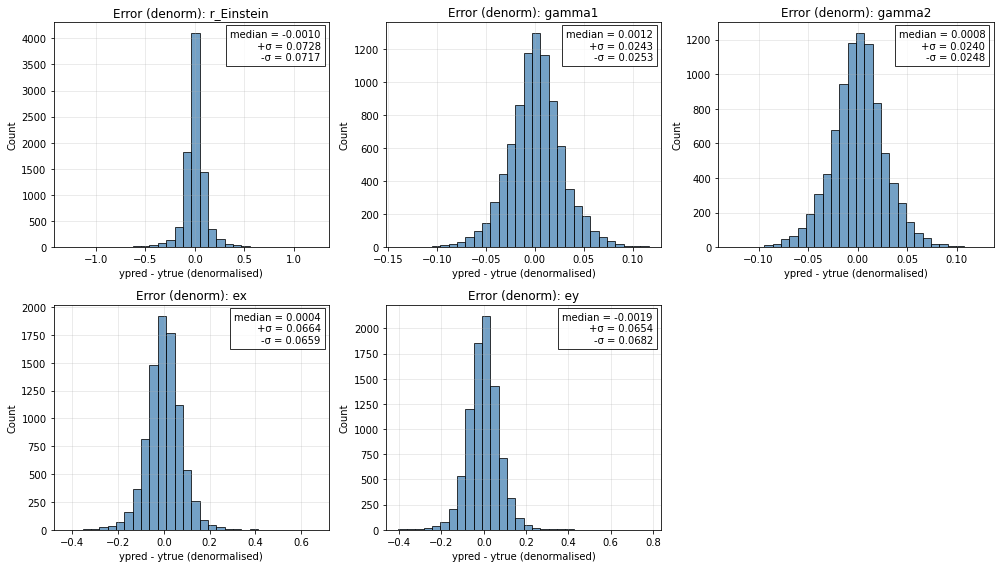

In [38]:
# import torch
# import numpy as np
# import matplotlib.pyplot as plt

# # --- Min/max used for normalization ---
# df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
# df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values
# scale = df_max - df_min   # range for each parameter

# # --- Convert to numpy ---
# y_true = targets.numpy()
# y_pred = preds.numpy()

# # --- DENORMALIZATION ---
# y_true_denorm = y_true * scale + df_min
# y_pred_denorm = y_pred * scale + df_min

# # --- Compute denormalised errors ---
# error_denorm = y_pred_denorm - y_true_denorm

# # --- Asymmetric statistics ---
# medians = np.median(error_denorm, axis=0)
# p16 = np.percentile(error_denorm, 16, axis=0)
# p84 = np.percentile(error_denorm, 84, axis=0)

# sigma_minus = medians - p16
# sigma_plus  = p84 - medians

# param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

# # --- Plot ---
# plt.figure(figsize=(14, 8))

# for i in range(error_denorm.shape[1]):
#     plt.subplot(2, 3, i+1)
#     plt.hist(error_denorm[:, i], bins=30, alpha=0.75,
#              color="steelblue", edgecolor="black")
#     plt.title(f"Error (denorm): {param_names[i]}")
#     plt.xlabel("ypred - ytrue (denormalised)")
#     plt.ylabel("Count")
#     plt.grid(alpha=0.3)

#     # --- Add text box with denormalised stats ---
#     text = (
#         f"median = {medians[i]:.4f}\n"
#         f"+σ = {sigma_plus[i]:.4f}\n"
#         f"-σ = {sigma_minus[i]:.4f}"
#     )

#     plt.text(
#         0.97, 0.97, text,
#         transform=plt.gca().transAxes,
#         fontsize=10,
#         ha="right", va="top",
#         bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
#     )

# plt.tight_layout()
# plt.show()
